# 06 - Routing: Query-Directed Multi-Index Retrieval

This notebook evaluates whether routing a query to a smaller topic-specific vector index can preserve retrieval quality while reducing the search space. The latest run uses 9,137 chunks split into five balanced ML-systems categories with no unclassified chunks.

| Category | Chunks | Content type |
|---|---:|---|
| **foundations** | 1,966 | Early ML systems, deployment paradigms, TinyML, edge/cloud/mobile ML |
| **training_efficiency** | 1,951 | Data engineering, frameworks, training, efficient AI, optimization, acceleration, benchmarking |
| **operations_robustness** | 2,052 | MLOps, on-device learning, security, privacy, robustness, production reliability |
| **trust_frontiers** | 1,607 | Responsible/sustainable AI, AI for good, AGI systems, scaling hypothesis |
| **references_research** | 1,561 | Textbook back matter and external research papers |

The split is reasonably balanced: the smallest non-empty category has 76% as many chunks as the largest.


## 0. Setup

In [7]:
import importlib
import json
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loaders import load_documents_from_directory
from src.ingestion.cleaners import clean_corpus
from src.ingestion.chunkers import chunk_recursive
from src.embeddings.models import create_from_registry
import src.chains.routing as routing_module
importlib.reload(routing_module)
from src.chains.routing import (
    BENCHMARK_TO_ROUTING,
    VALID_CATEGORIES,
    compute_centroids,
    route_category_from_metadata,
    route_and_retrieve,
    retrieve_no_routing,
 )
from notebooks.utils.display import (
    display_strategy_comparison,
    display_latency_comparison,
 )
from notebooks.utils.metrics import (
    load_benchmark_questions,
    compute_retrieval_metrics,
 )

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/hunganh/Code/Python/course_qa_assist


---
## 1. Corpus Preparation

The corpus loads 2,703 PDF pages, cleans this to 2,666 core documents, then recursively chunks them into 9,137 chunks. Routing now uses `source` plus PDF `page` metadata: the large ML systems textbook is split by page ranges, while short research PDFs are assigned to `references_research`.

The latest category split covers every chunk: 1,966 foundations, 1,951 training/efficiency, 2,052 operations/robustness, 1,607 trust/frontiers, and 1,561 references/research. No chunks are unclassified.


In [8]:
# Load and clean
docs = load_documents_from_directory(str(PROJECT_ROOT / "data" / "lectures"))
cleaned_docs, _ = clean_corpus(docs, min_content_length=50)

# Filter: keep only core docs (exclude /python/integrations/ noise)
core_docs = [
    d for d in cleaned_docs
    if "/python/integrations/" not in d.metadata.get("source", "")
]
print(f"Corpus: {len(docs)} docs -> {len(cleaned_docs)} cleaned -> {len(core_docs)} core")

# Chunk
result = chunk_recursive(core_docs, chunk_size=1000, chunk_overlap=200)
chunks = result.chunks
print(f"Chunked: {len(core_docs)} docs -> {len(chunks)} chunks")

Loaded 2703 document pages from /home/hunganh/Code/Python/course_qa_assist/data/lectures
Corpus: 2703 docs -> 2666 cleaned -> 2666 core
Chunked: 2666 docs -> 9137 chunks


In [9]:
# Split chunks into routing categories using source + page metadata
category_chunks: dict[str, list] = {cat: [] for cat in VALID_CATEGORIES}

unclassified = []
for chunk in chunks:
    cat = route_category_from_metadata(chunk.metadata)
    if cat in category_chunks:
        category_chunks[cat].append(chunk)
    else:
        unclassified.append(chunk)

print("Chunks per routing category:")
for cat in VALID_CATEGORIES:
    print(f"  {cat}: {len(category_chunks[cat])} chunks")
print(f"  unclassified: {len(unclassified)} chunks")
print(f"  total: {len(chunks)} chunks")

category_counts = {cat: len(category_chunks[cat]) for cat in VALID_CATEGORIES}
non_empty_counts = [count for count in category_counts.values() if count > 0]
if non_empty_counts:
    balance_ratio = min(non_empty_counts) / max(non_empty_counts)
    print(f"  balance ratio (min/max non-empty): {balance_ratio:.2f}")


Chunks per routing category:
  foundations: 1966 chunks
  training_efficiency: 1951 chunks
  operations_robustness: 2052 chunks
  trust_frontiers: 1607 chunks
  references_research: 1561 chunks
  unclassified: 0 chunks
  total: 9137 chunks
  balance ratio (min/max non-empty): 0.76


In [10]:
import chromadb
from langchain_chroma import Chroma

PERSIST_DIR = str(PROJECT_ROOT / "vectorstore" / "chroma_db")
MODELS_YAML = str(PROJECT_ROOT / "configs" / "models.yaml")

# Embedding model (same as Phase 4/5: mxbai-embed-large)
embeddings, emb_info = create_from_registry("mxbai_large", config_path=MODELS_YAML)
embeddings.embed_query("warmup")
print(f"Embedding model: {emb_info.model_id} ({emb_info.dimensions}d)")

Embedding model: mxbai-embed-large (1024d)


In [11]:
client = chromadb.PersistentClient(path=PERSIST_DIR)

# Collection names
COLLECTION_NAMES = {cat: f"routing_{cat}" for cat in VALID_CATEGORIES}
COLLECTION_NAMES["full"] = "routing_full"

for name in COLLECTION_NAMES.values():
    try:
        client.delete_collection(name)
    except Exception:
        pass

cat_vectorstores: dict[str, Chroma] = {}
for cat, cat_name in [(k, v) for k, v in COLLECTION_NAMES.items() if k != "full"]:
    cat_ch = category_chunks.get(cat, [])
    if not cat_ch:
        continue
    cat_vectorstores[cat] = Chroma.from_documents(
        documents=cat_ch,
        embedding=embeddings,
        persist_directory=PERSIST_DIR,
        collection_name=cat_name,
    )
    print(f"Created {cat_name} with {len(cat_ch)} chunks")

# Full collection for the no-routing baseline
full_vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=PERSIST_DIR,
    collection_name=COLLECTION_NAMES["full"],
)
print(f"Created {COLLECTION_NAMES['full']} with {len(chunks)} chunks")


Created routing_foundations with 1966 chunks
Created routing_training_efficiency with 1951 chunks
Created routing_operations_robustness with 2052 chunks
Created routing_trust_frontiers with 1607 chunks
Created routing_references_research with 1561 chunks
Created routing_full with 9137 chunks


In [12]:
# Load benchmark questions
questions = load_benchmark_questions(
    str(PROJECT_ROOT / "data" / "evaluation" / "benchmark_retrieval.json")
)

# This benchmark's categories are broad, so use question-level expectations
# for routing accuracy where the target textbook section is known.
BENCHMARK_QUERY_TO_ROUTING = {
    "q1": "foundations",          # TinyML / deployment paradigms
    "q2": "trust_frontiers",      # AGI systems
    "q3": "foundations",          # autonomous vehicles / real-time ML systems
    "q4": "foundations",          # large-scale ML systems coordination
    "q5": "trust_frontiers",      # Scaling Hypothesis / AGI
}

def expected_routing_category(question) -> str:
    return BENCHMARK_QUERY_TO_ROUTING.get(
        question.id,
        BENCHMARK_TO_ROUTING.get(question.category, "?"),
    )

categories = {}
for q in questions:
    categories.setdefault(q.category, []).append(q)

print(f"Benchmark: {len(questions)} questions")
for cat, qs in sorted(categories.items()):
    expected_routes = sorted({expected_routing_category(q) for q in qs})
    print(f"  {cat}: {len(qs)} questions -> routes to {expected_routes}")


Benchmark: 5 questions
  methodology: 3 questions -> routes to ['foundations', 'trust_frontiers']
  results: 2 questions -> routes to ['foundations', 'trust_frontiers']


---
## 2. Baseline: No Routing

The baseline searches the full 9,137-chunk collection. It remains the strongest overall reference point in this run: Precision@5 and Recall@5 are both 0.7600, MRR is 0.8667, nDCG@5 is 0.7755, and average latency is 24.0 ms.


In [13]:
K = 5

baseline_metrics = []
for q in questions:
    result = retrieve_no_routing(full_vectorstore, q.query, k=K)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "no_routing"
    m["llm_calls"] = result.llm_calls
    m["predicted_category"] = result.predicted_category
    baseline_metrics.append(m)

baseline_df = pd.DataFrame(baseline_metrics)
print("Baseline (no routing):")
print(f"  Precision@{K}: {baseline_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {baseline_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {baseline_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {baseline_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {baseline_df['latency_ms'].mean():.1f} ms")

Baseline (no routing):
  Precision@5: 0.7600
  Recall@5:    0.7600
  MRR:           0.8667
  nDCG@5:      0.7755
  Latency:       24.0 ms


---
## 3. Logical Routing (LLM-based)

Logical routing asks `mistral:7b` to classify each query into one of the five balanced course categories, then retrieves only from that sub-index. It made one LLM call per query.

In the latest run, logical routing classified 4 of 5 benchmark questions correctly. The miss was the AGI systems question, routed to `references_research` instead of `trust_frontiers`. Retrieval quality dropped below the full-index baseline: Precision@5 was 0.6800, MRR was 0.8000, and latency rose to 121.9 ms because of the LLM classification step.


In [14]:
from langchain_ollama import ChatOllama
from src.chains.routing import classify_logical

llm = ChatOllama(model="mistral:7b", temperature=0.0)

# Warmup
_ = llm.invoke("Say 'ok'.")
print("LLM: mistral:7b (Ollama) - ready")

LLM: mistral:7b (Ollama) - ready


In [15]:
# Show routing decisions for a sample of queries
print("Logical routing examples:")
print(f"{'Query':<60} {'Predicted':<15} {'Expected'}")
print("-" * 90)

for q in questions[:8]:
    predicted = classify_logical(llm, q.query)
    expected = expected_routing_category(q)
    match = "OK" if predicted == expected else "MISS"
    print(f"{q.query[:58]:<60} {predicted:<15} {expected} {match}")

Logical routing examples:
Query                                                        Predicted       Expected
------------------------------------------------------------------------------------------
What are the primary characteristics and constraints of Ti   foundations     foundations OK
How is Artificial General Intelligence (AGI) defined as a    references_research trust_frontiers MISS
What are the connectivity requirements for autonomous vehi   foundations     foundations OK
How do large-scale ML systems manage coordination strategi   foundations     foundations OK
What role does the Scaling Hypothesis play in the developm   trust_frontiers trust_frontiers OK


In [16]:
print(f"Logical routing benchmark ({len(questions)} questions)...\n")

logical_metrics = []
logical_routing_decisions = []

for i, q in enumerate(questions):
    result = route_and_retrieve(
        query=q.query,
        technique="logical",
        collections=cat_vectorstores,
        llm=llm,
        k=K,
    )
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "logical"
    m["llm_calls"] = result.llm_calls
    m["predicted_category"] = result.predicted_category
    logical_metrics.append(m)
    logical_routing_decisions.append({
        "query": q.query,
        "predicted": result.predicted_category,
        "expected": expected_routing_category(q),
        "benchmark_category": q.category,
    })
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(questions)} done...")

logical_df = pd.DataFrame(logical_metrics)
print(f"\nLogical routing:")
print(f"  Precision@{K}: {logical_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {logical_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {logical_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {logical_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {logical_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {logical_df['llm_calls'].mean():.0f}")

Logical routing benchmark (5 questions)...

  5/5 done...

Logical routing:
  Precision@5: 0.6800
  Recall@5:    0.6800
  MRR:           0.8000
  nDCG@5:      0.7059
  Latency:       121.9 ms
  LLM calls/q:   1


In [17]:
# Routing accuracy analysis
routing_df = pd.DataFrame(logical_routing_decisions)
routing_df["correct"] = routing_df["predicted"] == routing_df["expected"]

accuracy = routing_df["correct"].mean()
print(f"Logical routing accuracy: {accuracy:.1%} ({routing_df['correct'].sum()}/{len(routing_df)})")

print("\nAccuracy by benchmark category:")
display(routing_df.groupby("benchmark_category")["correct"].agg(["sum", "count", "mean"]).round(3))

Logical routing accuracy: 80.0% (4/5)

Accuracy by benchmark category:


,sum,count,mean
benchmark_category,,,
methodology,2,3,0.667
results,2,2,1.000


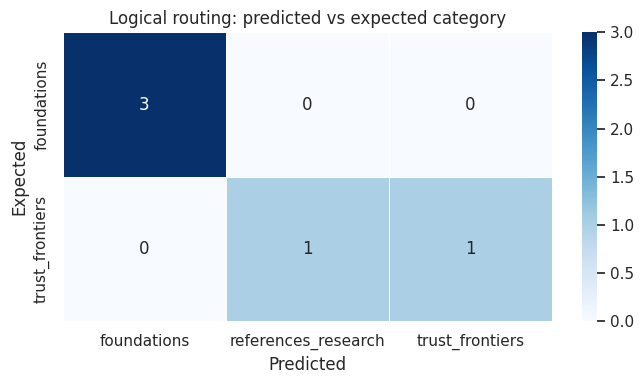

In [18]:
# Confusion matrix: predicted routing category vs expected
confusion = pd.crosstab(
    routing_df["expected"],
    routing_df["predicted"],
    rownames=["Expected"],
    colnames=["Predicted"],
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    confusion,
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Logical routing: predicted vs expected category")
plt.tight_layout()
plt.show()

---
## 4. Semantic Routing (Embedding-based)

Semantic routing embeds the query and compares it to category centroids. The centroids are computed from raw page-level documents per category, not from final chunks. This is a one-time setup cost; in this run centroid computation took 88.4 seconds.

At query time, semantic routing needs no LLM calls. It also routed 4 of 5 questions correctly, with mean confidence 0.716 and no fallback-to-all searches. It matched the baseline on Precision@5 and Recall@5 at 0.7600, but MRR was lower at 0.8000. Average latency was 40.7 ms, faster than logical routing but slower than the 24.0 ms full-index baseline.


In [19]:
# Compute centroid embeddings for each category
# This is a one-time operation (can be cached)
print("Computing category centroids...")
start = time.perf_counter()

# Use the raw doc texts (not chunks) for centroid computation - more stable
category_docs_for_centroid = {cat: [] for cat in VALID_CATEGORIES}
for doc in core_docs:
    cat = route_category_from_metadata(doc.metadata)
    if cat in category_docs_for_centroid:
        category_docs_for_centroid[cat].append(doc)

print("Docs per category for centroid computation:")
for cat, cat_docs in category_docs_for_centroid.items():
    print(f"  {cat}: {len(cat_docs)} docs")

centroids = compute_centroids(category_docs_for_centroid, embeddings)
elapsed = time.perf_counter() - start
print(f"\nCentroids computed in {elapsed:.1f}s")
for cat, centroid in centroids.items():
    print(f"  {cat}: shape={centroid.shape}, norm={np.linalg.norm(centroid):.3f}")

Computing category centroids...
Docs per category for centroid computation:
  foundations: 512 docs
  training_efficiency: 518 docs
  operations_robustness: 518 docs
  trust_frontiers: 510 docs
  references_research: 608 docs

Centroids computed in 88.4s
  foundations: shape=(1024,), norm=0.805
  training_efficiency: shape=(1024,), norm=0.833
  operations_robustness: shape=(1024,), norm=0.797
  trust_frontiers: shape=(1024,), norm=0.764
  references_research: shape=(1024,), norm=0.751


In [20]:
# Show semantic routing decisions with similarity scores
from src.chains.routing import classify_semantic

categories = list(VALID_CATEGORIES)
print("Semantic routing examples (cosine similarity to each centroid):")
header = f"{'Query':<55} {'Best':<15} " + " ".join([f"{cat:<14}" for cat in categories]) + "Expected"
print(header)
print("-" * len(header))

for q in questions[:8]:
    q_emb = np.array(embeddings.embed_query(q.query))
    sims = {}
    for cat in categories:
        centroid = centroids.get(cat)
        if centroid is None:
            sims[cat] = float("nan")
        else:
            sims[cat] = float(np.dot(q_emb, centroid) / (np.linalg.norm(q_emb) * np.linalg.norm(centroid)))
    best_cat, confidence = classify_semantic(q_emb, centroids)
    expected = expected_routing_category(q)
    match = "OK" if best_cat == expected else "MISS"
    sim_str = " ".join([f"{sims[cat]:<14.3f}" for cat in categories])
    print(
        f"{q.query[:53]:<55} {best_cat:<15} {sim_str} {expected} {match}"
    )

Semantic routing examples (cosine similarity to each centroid):
Query                                                   Best            foundations    training_efficiency operations_robustness trust_frontiers references_researchExpected
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
What are the primary characteristics and constraints    foundations     0.714          0.657          0.690          0.701          0.702          foundations OK
How is Artificial General Intelligence (AGI) defined    trust_frontiers 0.625          0.581          0.613          0.689          0.587          trust_frontiers OK
What are the connectivity requirements for autonomous   trust_frontiers 0.690          0.638          0.681          0.701          0.683          foundations MISS
How do large-scale ML systems manage coordination str   foundations     0.789          0.754      

In [21]:
print(f"Semantic routing benchmark ({len(questions)} questions)...\n")

semantic_metrics = []
semantic_routing_decisions = []

for i, q in enumerate(questions):
    result = route_and_retrieve(
        query=q.query,
        technique="semantic",
        collections=cat_vectorstores,
        embeddings=embeddings,
        centroids=centroids,
        k=K,
        fallback_threshold=0.3,
    )
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "semantic"
    m["llm_calls"] = result.llm_calls
    m["predicted_category"] = result.predicted_category
    m["confidence"] = result.confidence
    semantic_metrics.append(m)
    semantic_routing_decisions.append({
        "query": q.query,
        "predicted": result.predicted_category,
        "expected": expected_routing_category(q),
        "benchmark_category": q.category,
        "confidence": result.confidence,
    })

semantic_df = pd.DataFrame(semantic_metrics)
print(f"Semantic routing:")
print(f"  Precision@{K}: {semantic_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {semantic_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {semantic_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {semantic_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {semantic_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {semantic_df['llm_calls'].mean():.0f}")

Semantic routing benchmark (5 questions)...

Semantic routing:
  Precision@5: 0.7600
  Recall@5:    0.7600
  MRR:           0.8000
  nDCG@5:      0.7661
  Latency:       40.7 ms
  LLM calls/q:   0


In [22]:
# Routing accuracy for semantic
sem_routing_df = pd.DataFrame(semantic_routing_decisions)
sem_routing_df["correct"] = sem_routing_df["predicted"] == sem_routing_df["expected"]

sem_accuracy = sem_routing_df["correct"].mean()
print(f"Semantic routing accuracy: {sem_accuracy:.1%} ({sem_routing_df['correct'].sum()}/{len(sem_routing_df)})")
print(f"Mean confidence: {sem_routing_df['confidence'].mean():.3f}")
print(f"Fallbacks (category='all'): {(sem_routing_df['predicted'] == 'all').sum()}")

print("\nAccuracy by benchmark category:")
display(sem_routing_df.groupby("benchmark_category")["correct"].agg(["sum", "count", "mean"]).round(3))

Semantic routing accuracy: 80.0% (4/5)
Mean confidence: 0.716
Fallbacks (category='all'): 0

Accuracy by benchmark category:


,sum,count,mean
benchmark_category,,,
methodology,2,3,0.667
results,2,2,1.000


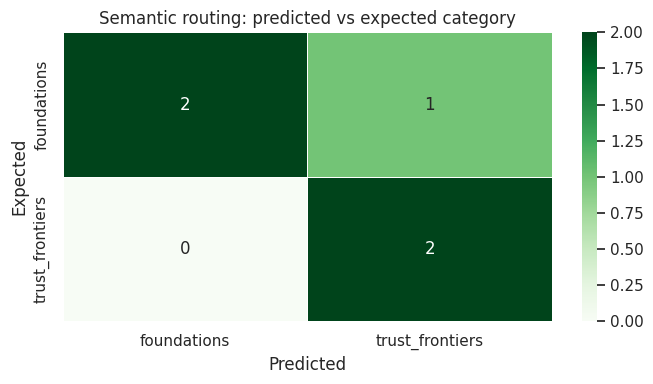

In [23]:
# Confusion matrix for semantic routing
sem_confusion = pd.crosstab(
    sem_routing_df["expected"],
    sem_routing_df["predicted"],
    rownames=["Expected"],
    colnames=["Predicted"],
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    sem_confusion,
    annot=True, fmt="d",
    cmap="Greens",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Semantic routing: predicted vs expected category")
plt.tight_layout()
plt.show()

---
## 5. Routing Accuracy Comparison

Both routing methods achieved 80.0% overall routing accuracy on the 5-question benchmark. Accuracy was 66.7% on `methodology` questions and 100.0% on `results` questions for both logical and semantic routing.

Because the benchmark labels are broad, routing accuracy uses question-level expected routes defined in the notebook rather than only the `methodology`/`results` labels.


In [24]:
# Compare routing accuracy side by side
routing_compare = pd.DataFrame({
    "benchmark_category": routing_df["benchmark_category"],
    "logical_correct": routing_df["correct"],
    "semantic_correct": sem_routing_df["correct"],
})

acc_by_cat = routing_compare.groupby("benchmark_category").agg(
    logical_accuracy=("logical_correct", "mean"),
    semantic_accuracy=("semantic_correct", "mean"),
    n=("logical_correct", "count"),
).round(3)

print("Routing accuracy by query category:")
display(acc_by_cat)
print(f"\nOverall accuracy:")
print(f"  Logical:  {routing_df['correct'].mean():.1%}")
print(f"  Semantic: {sem_routing_df['correct'].mean():.1%}")

Routing accuracy by query category:


,logical_accuracy,semantic_accuracy,n
benchmark_category,,,
methodology,0.667,0.667,3
results,1.000,1.000,2



Overall accuracy:
  Logical:  80.0%
  Semantic: 80.0%


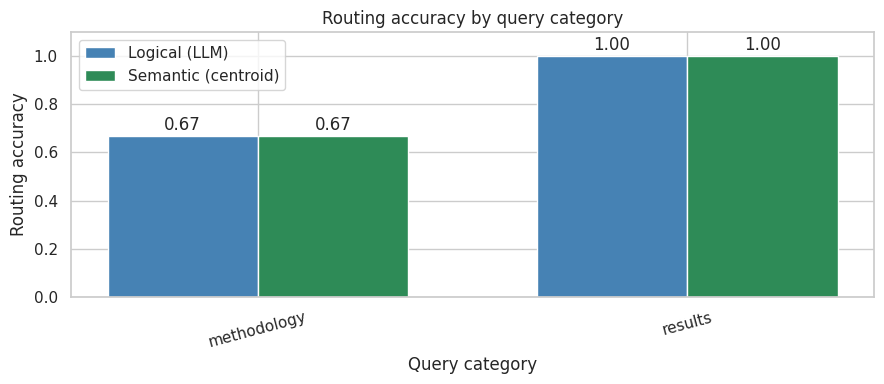

In [25]:
# Bar chart: accuracy by category
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(acc_by_cat))
width = 0.35

bars1 = ax.bar(x - width/2, acc_by_cat["logical_accuracy"], width, label="Logical (LLM)", color="steelblue")
bars2 = ax.bar(x + width/2, acc_by_cat["semantic_accuracy"], width, label="Semantic (centroid)", color="seagreen")

ax.set_xlabel("Query category")
ax.set_ylabel("Routing accuracy")
ax.set_title("Routing accuracy by query category")
ax.set_xticks(x)
ax.set_xticklabels(acc_by_cat.index, rotation=15)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=2)
ax.bar_label(bars2, fmt="%.2f", padding=2)
plt.tight_layout()
plt.show()

---
## 6. Global Retrieval Comparison

The full-index baseline still has the best MRR and lowest latency. Semantic routing is the best routed option here: it keeps Precision@5 at 0.7600 and avoids LLM calls, but its MRR drops from 0.8667 to 0.8000 and latency increases from 24.0 ms to 40.7 ms. Logical routing is the weakest option in this run, with lower Precision@5 at 0.6800 and the highest latency at 121.9 ms.


In [26]:
# Combine all results
all_metrics_df = pd.concat(
    [baseline_df, logical_df, semantic_df],
    ignore_index=True,
)

summary = (
    all_metrics_df.groupby("strategy")
    .agg(
        avg_precision=("precision_at_k", "mean"),
        avg_recall=("recall_at_k", "mean"),
        avg_mrr=("mrr", "mean"),
        avg_ndcg=("ndcg_at_k", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
        avg_llm_calls=("llm_calls", "mean"),
    )
    .round(4)
)

print("Global comparison (routing strategies vs baseline):")
display_strategy_comparison(summary.reset_index())

Global comparison (routing strategies vs baseline):


,strategy,avg_precision,avg_recall,avg_mrr,avg_ndcg,avg_latency_ms,avg_llm_calls
0,logical,0.680000,0.680000,0.800000,0.705900,121.9,1.000000
1,no_routing,0.760000,0.760000,0.866700,0.775500,24.0,0.000000
2,semantic,0.760000,0.760000,0.800000,0.766100,40.7,0.000000


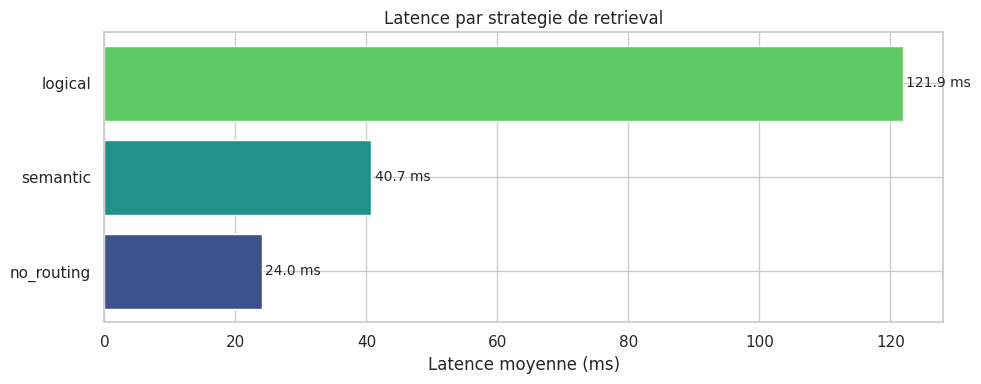


MRR vs Latency:


,avg_mrr,avg_latency_ms,avg_llm_calls,vs_baseline
strategy,,,,
logical,0.8000,121.94,1.0,-0.0667
no_routing,0.8667,23.98,0.0,0.0000
semantic,0.8000,40.74,0.0,-0.0667


In [27]:
# Latency comparison
latency_df = summary.reset_index()[["strategy", "avg_latency_ms"]]
display_latency_comparison(latency_df)

print("\nMRR vs Latency:")
tradeoff = summary.reset_index()[["strategy", "avg_mrr", "avg_latency_ms", "avg_llm_calls"]].copy()
tradeoff["vs_baseline"] = (tradeoff["avg_mrr"] - tradeoff.loc[tradeoff["strategy"] == "no_routing", "avg_mrr"].values[0]).round(4)
display(tradeoff.set_index("strategy"))

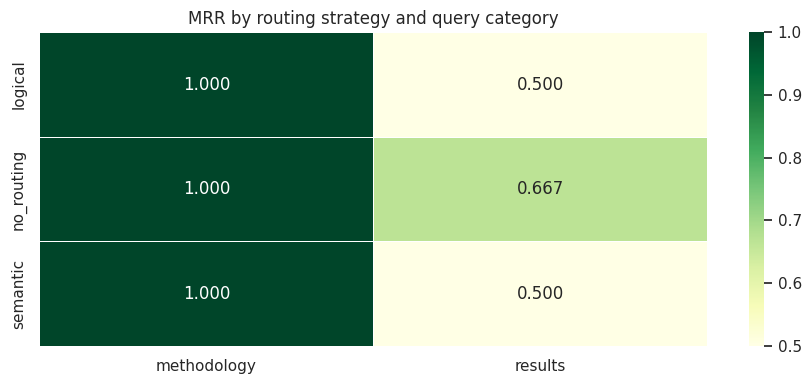

In [28]:
# MRR by strategy and query category
cat_summary = (
    all_metrics_df.groupby(["category", "strategy"])
    .agg(avg_mrr=("mrr", "mean"))
    .round(4)
    .reset_index()
)

pivot = cat_summary.pivot(index="strategy", columns="category", values="avg_mrr")

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    pivot,
    annot=True, fmt=".3f",
    cmap="YlGn",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("MRR by routing strategy and query category")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

---
## 7. Save Results

The saved JSON records the balanced category split, routing accuracy, and retrieval metrics for `no_routing`, `logical`, and `semantic`. The latest result file shows logical and semantic routing accuracy at 0.8, with semantic routing matching baseline Precision@5 but not baseline MRR.


In [29]:
# Build category counts from questions (avoids relying on a mutable variable name)
category_counts = {}
for q in questions:
    category_counts[q.category] = category_counts.get(q.category, 0) + 1

results_output = {
    "phase": 6,
    "corpus": {
        "num_raw_docs": len(docs),
        "num_cleaned_docs": len(cleaned_docs),
        "num_core_docs": len(core_docs),
        "num_chunks": len(chunks),
        "filter": "excluded /python/integrations/ pages",
        "chunking_strategy": "recursive",
        "chunk_size": 1000,
        "chunk_overlap": 200,
        "embedding_model": emb_info.model_id,
        "category_split": {
            cat: len(ch) for cat, ch in category_chunks.items()
        },
    },
    "benchmark": {
        "num_questions": len(questions),
        "k": K,
        "categories": dict(sorted(category_counts.items())),
    },
    "llm": "mistral:7b",
    "routing_accuracy": {
        "logical": round(float(routing_df["correct"].mean()), 4),
        "semantic": round(float(sem_routing_df["correct"].mean()), 4),
    },
    "techniques": {},
}

for technique, group in all_metrics_df.groupby("strategy"):
    entry = {
        "avg_precision_at_k": round(float(group["precision_at_k"].mean()), 4),
        "avg_recall_at_k": round(float(group["recall_at_k"].mean()), 4),
        "avg_mrr": round(float(group["mrr"].mean()), 4),
        "avg_ndcg_at_k": round(float(group["ndcg_at_k"].mean()), 4),
        "avg_latency_ms": round(float(group["latency_ms"].mean()), 1),
        "avg_llm_calls": round(float(group["llm_calls"].mean()), 1),
        "per_category": {},
    }
    for cat, cat_group in group.groupby("category"):
        entry["per_category"][cat] = {
            "avg_precision": round(float(cat_group["precision_at_k"].mean()), 4),
            "avg_mrr": round(float(cat_group["mrr"].mean()), 4),
            "avg_latency_ms": round(float(cat_group["latency_ms"].mean()), 1),
        }
    results_output["techniques"][technique] = entry

results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
output_path = results_dir / "routing_comparison.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_output, f, indent=2, ensure_ascii=False)

print(f"Results saved to {output_path}")

Results saved to /home/hunganh/Code/Python/course_qa_assist/results/routing_comparison.json


---
## 8. Cleanup

The cleanup cell deletes the temporary collections created by this notebook: the five routed collections and the full routing baseline collection. The remaining `routing_theoretical` collection shown in the output is from an older routing run and is not used by the current notebook.


In [30]:
for name in COLLECTION_NAMES.values():
    try:
        client.delete_collection(name)
        print(f"Deleted collection: {name}")
    except Exception:
        pass

print(f"Remaining collections: {[c.name for c in client.list_collections()]}")

Deleted collection: routing_foundations
Deleted collection: routing_training_efficiency
Deleted collection: routing_operations_robustness
Deleted collection: routing_trust_frontiers
Deleted collection: routing_references_research
Deleted collection: routing_full
Remaining collections: ['course_qa_naive', 'routing_theoretical']


---
## 9. Summary & Observations

### Results

| Strategy | Precision@5 | MRR | nDCG@5 | Latency | LLM calls | Routing accuracy |
|---|---:|---:|---:|---:|---:|---:|
| No routing | **0.7600** | **0.8667** | **0.7755** | **24.0 ms** | 0 | n/a |
| Semantic routing | **0.7600** | 0.8000 | 0.7661 | 40.7 ms | 0 | 80.0% |
| Logical routing | 0.6800 | 0.8000 | 0.7059 | 121.9 ms | 1 | 80.0% |

### Key Takeaways

1. **The category split is now balanced enough for routing experiments.** All 9,137 chunks are classified, and the min/max non-empty category balance ratio is 0.76.

2. **Routing accuracy improved to 80%.** Both logical and semantic routing correctly routed 4 of 5 benchmark questions. The remaining mistakes affected ranking quality.

3. **No-routing is still the strongest baseline.** It has the best MRR, best nDCG@5, and lowest latency on this small benchmark.

4. **Semantic routing is the more practical routed strategy.** It avoids LLM calls and keeps Precision@5 equal to baseline, but it adds one embedding/classification step and loses 0.0667 MRR.

5. **Logical routing is not worth the cost here.** It is slower due to one LLM call per query and performs worse than semantic routing on Precision@5 and nDCG@5.

### When to use routing

| Scenario | Use routing? |
|---|---|
| Small benchmark and strong full-index search | Prefer no-routing |
| Balanced topic indexes and no LLM overhead desired | Try semantic routing |
| Need human-readable route decisions | Logical routing is interpretable but slower |
| Routing mistakes remove relevant context | Use fallback or search multiple candidate routes |
